# Inspect Stain Processing
Quick checks for Macenko normalization and color-space conversion (LAB/HSV/HED).

This notebook uses a small subset for speed.

## Fit Normalizer (Small Subset)
Fits Macenko on a tiny subset and compares original vs normalized images to see stain consistency.

Selecting reference from 50 candidates...
Fit OK — image 33  (OD=0.3510, tissue=0.998)
Selected reference index: 33


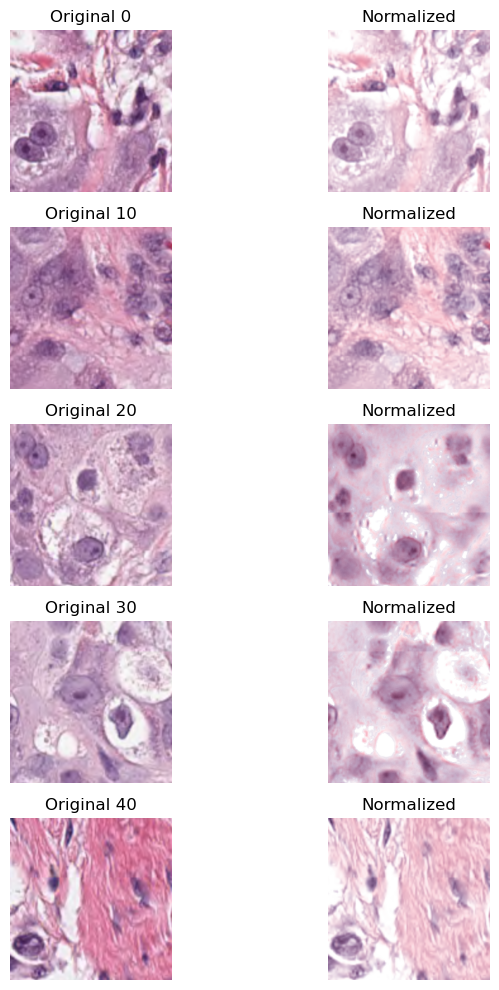

In [1]:
from pathlib import Path
import importlib
import sys
from unittest.mock import MagicMock

# Make the repo importable even if the kernel starts in notebooks/.
project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

# StainTools may import optional deps we do not use (Vahadane/SPAMS).
sys.modules['spams'] = MagicMock()

import numpy as np
import matplotlib.pyplot as plt
import src.preprocessing.stain_normalizer as stain_normalizer_mod
importlib.reload(stain_normalizer_mod)
MacenkoNormalizer = stain_normalizer_mod.MacenkoNormalizer

images_path = project_root / "data" / "raw" / "Fold1" / "images" / "fold1" / "images.npy"
images = np.load(images_path, mmap_mode="r")

normalizer = MacenkoNormalizer()
fit_subset = images[:50]
normalizer.fit(fit_subset)
print("Selected reference index:", normalizer.reference_index)

idxs = [0, 10, 20, 30, 40]
fig, axes = plt.subplots(len(idxs), 2, figsize=(8, 2 * len(idxs)))
for row, idx in enumerate(idxs):
    original = images[idx].astype(np.uint8)
    normalized = normalizer.transform(original)
    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"Original {idx}")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(normalized)
    axes[row, 1].set_title("Normalized")
    axes[row, 1].axis("off")
plt.tight_layout()

## Color-Space Conversion (LAB/HSV/HED)
Checks for NaNs/Infs and validates that the HED H-channel is stronger inside nuclei.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.preprocessing.color_converter import convert_image
from src.data.label_generator import generate_binary_labels

masks_path = project_root / "data" / "raw"  / "Fold1" / "masks" / "fold1" / "masks.npy"
masks = np.load(masks_path, mmap_mode="r")

img = images[0].astype(np.uint8)
mask = masks[0]

spaces = convert_image(img)
for name, arr in spaces.items():
    print(f"{name}: shape={arr.shape}, min={arr.min():.3f}, max={arr.max():.3f}")
    assert not np.isnan(arr).any(), f"NaN in {name}"
    assert not np.isinf(arr).any(), f"Inf in {name}"

binary_lbl = generate_binary_labels(mask)
h_nucleus = spaces['hed'][:, :, 0][binary_lbl == 1].mean()
h_background = spaces['hed'][:, :, 0][binary_lbl == 0].mean()
print(f"H channel mean at nucleus: {h_nucleus:.4f}")
print(f"H channel mean at background: {h_background:.4f}")

rgb: shape=(256, 256, 3), min=28.000, max=255.000
lab: shape=(256, 256, 3), min=-31.055, max=98.642
hsv: shape=(256, 256, 3), min=0.000, max=1.000
hed: shape=(256, 256, 3), min=0.000, max=0.233
H channel mean at nucleus: 0.0705
H channel mean at background: 0.0290


## Visualize Channels
Shows how LAB/HSV/HED separate structure and stain components.

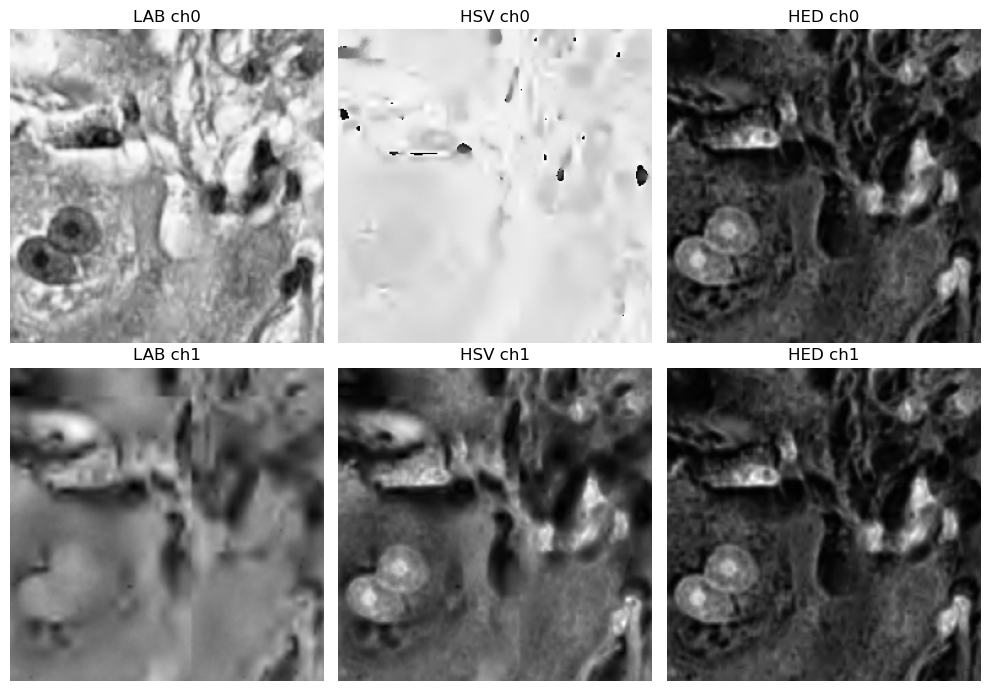

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
channel_sets = [
    ("LAB", spaces['lab']),
    ("HSV", spaces['hsv']),
    ("HED", spaces['hed']),
]

for col, (name, arr) in enumerate(channel_sets):
    axes[0, col].imshow(arr[:, :, 0], cmap="gray")
    axes[0, col].set_title(f"{name} ch0")
    axes[0, col].axis("off")
    axes[1, col].imshow(arr[:, :, 1], cmap="gray")
    axes[1, col].set_title(f"{name} ch1")
    axes[1, col].axis("off")
plt.tight_layout()

In [ ]:
S